# Homework 5 — Neural Networks on the Census (Adult) Dataset

In this notebook I build and evaluate feed-forward neural networks to predict whether a person's income exceeds \$50K using the UCI Adult census dataset. I reuse the feature-engine preprocessing pipeline from our in-class census work (rare-label encoding, frequency encoding, and equal-frequency discretization), then iterate on model architecture, regularization, and training settings before running an Optuna search for a final tuned model.

## 1. Setup and data loading

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from feature_engine.encoding import RareLabelEncoder, CountFrequencyEncoder
from feature_engine.discretisation import EqualFrequencyDiscretiser
from feature_engine.selection import DropConstantFeatures

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay,
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
EPOCHS = 25
BATCH_SIZE = 512
PATIENCE = 6

tf.keras.utils.set_random_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")

In [2]:
adult = pd.read_csv("../datasets/adult.csv")
adult.columns = [c.strip() for c in adult.columns]

# strip whitespace from string columns
for col in adult.select_dtypes(include="object").columns:
    adult[col] = adult[col].astype(str).str.strip()

# target: 1 = >50K, 0 = <=50K
adult["income"] = adult["income"].map({">50K": 1, "<=50K": 0})

# drop sampling weight and binarize gender (same choices as in-class notebooks)
adult = adult.drop(columns=["fnlwgt"])
adult["gender"] = adult["gender"].map({"Male": 1, "Female": 0})

# missing values
adult = adult.replace("?", np.nan)
num_cols_raw = adult.select_dtypes(include="number").columns.tolist()
cat_cols_raw = [c for c in adult.columns if c not in num_cols_raw and c != "income"]

for col in cat_cols_raw:
    adult[col] = adult[col].fillna("unknown")
for col in num_cols_raw:
    if col != "income":
        adult[col] = adult[col].fillna(adult[col].median())

print(f"Rows: {len(adult):,} | Positive class rate: {adult['income'].mean():.3f}")
adult.head()

Rows: 48,842 | Positive class rate: 0.239


,age,workclass,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,1,0,0,40,United-States,0
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,1,0,0,50,United-States,0
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,1,0,0,40,United-States,1
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,1,7688,0,40,United-States,1
4,18,unknown,Some-college,10,Never-married,unknown,Own-child,White,0,0,0,30,United-States,0


## 2. Feature preprocessing

This mirrors the `adult_fe` pipeline from `inclass_04_23.ipynb`:
1. Collapse rare categorical labels
2. Frequency-encode categoricals
3. Discretize numeric columns (except skewed/binary fields)
4. Drop any constant columns

All transformers are fit on the training split only to avoid leakage.

In [3]:
X = adult.drop(columns=["income"])
y = adult["income"]

# held-out test set (20%) — touched only at the end
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# validation set for early stopping and experiment comparison
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.15,
    random_state=RANDOM_STATE,
    stratify=y_train_full,
)

cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

rare_encoder = RareLabelEncoder(tol=0.01, variables=cat_cols)
X_train = rare_encoder.fit_transform(X_train)
X_val = rare_encoder.transform(X_val)
X_test = rare_encoder.transform(X_test)

freq_encoder = CountFrequencyEncoder(variables=cat_cols, encoding_method="frequency")
X_train = freq_encoder.fit_transform(X_train)
X_val = freq_encoder.transform(X_val)
X_test = freq_encoder.transform(X_test)

disc_vars = [c for c in num_cols if c not in ["gender", "capital-gain", "capital-loss"]]
disc = EqualFrequencyDiscretiser(q=5, variables=disc_vars)
X_train = disc.fit_transform(X_train)
X_val = disc.transform(X_val)
X_test = disc.transform(X_test)

const_drop = DropConstantFeatures()
X_train = const_drop.fit_transform(X_train)
X_val = const_drop.transform(X_val)
X_test = const_drop.transform(X_test)

print(f"Feature count after preprocessing: {X_train.shape[1]}")
X_train.head()

Feature count after preprocessing: 13


,age,workclass,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country
27300,1,0.692641,0.220372,1,0.330453,0.125979,0.106106,0.856648,1,0,0,1,0.898079
36690,3,0.692641,0.220372,1,0.456100,0.113604,0.401782,0.856648,1,0,0,1,0.898079
624,1,0.692641,0.324521,0,0.456100,0.061122,0.401782,0.856648,1,0,0,1,0.898079
15575,1,0.692641,0.324521,0,0.330453,0.100897,0.154041,0.094454,0,0,0,1,0.898079
9070,4,0.039925,0.032187,2,0.136878,0.113604,0.259063,0.856648,0,0,0,0,0.898079


In [4]:
# neural nets benefit from scaled inputs
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

INPUT_DIM = X_train_s.shape[1]
print(f"Train: {X_train_s.shape} | Val: {X_val_s.shape} | Test: {X_test_s.shape}")

Train: (33212, 13) | Val: (5861, 13) | Test: (9769, 13)


## 3. Reusable training utilities

In [5]:
def build_mlp(
    hidden_units=(64,),
    dropout=0.0,
    l2=0.0,
    learning_rate=1e-3,
    input_dim=INPUT_DIM,
):
    model = keras.Sequential([keras.Input(shape=(input_dim,))], name="census_mlp")
    for i, units in enumerate(hidden_units):
        model.add(
            layers.Dense(
                units,
                activation="relu",
                kernel_regularizer=regularizers.l2(l2) if l2 else None,
                name=f"dense_{i + 1}",
            )
        )
        if dropout > 0:
            model.add(layers.Dropout(dropout, name=f"dropout_{i + 1}"))
    model.add(layers.Dense(1, activation="sigmoid", name="output"))
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.AUC(name="auc"),
        ],
    )
    return model


def evaluate_model(model, X, y):
    probs = model.predict(X, verbose=0).ravel()
    preds = (probs >= 0.5).astype(int)
    return {
        "balanced_accuracy": balanced_accuracy_score(y, preds),
        "roc_auc": roc_auc_score(y, probs),
        "probs": probs,
        "preds": preds,
    }


def train_model(
    model,
    X_tr,
    y_tr,
    X_va,
    y_va,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    patience=PATIENCE,
    verbose=0,
):
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=patience,
            restore_best_weights=True,
        )
    ]
    history = model.fit(
        X_tr,
        y_tr,
        validation_data=(X_va, y_va),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=verbose,
    )
    return history


def plot_history(histories, metric="auc", title="Validation AUC by experiment"):
    plt.figure(figsize=(8, 4))
    for name, history in histories.items():
        val_metric = history.history.get(f"val_{metric}")
        if val_metric is not None:
            plt.plot(val_metric, label=name)
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(metric.upper())
    plt.legend()
    plt.tight_layout()
    plt.show()

## 4. Baseline neural network

Starting point: one hidden layer with 64 units, ReLU activations, Adam optimizer, no dropout or L2. This is intentionally simple so later changes are easy to interpret.

In [6]:
baseline = build_mlp(hidden_units=(64,))
baseline.summary()

baseline_history = train_model(
    baseline, X_train_s, y_train, X_val_s, y_val, verbose=1
)
baseline_metrics = evaluate_model(baseline, X_val_s, y_val)

print(
    f"Baseline validation balanced accuracy: {baseline_metrics['balanced_accuracy']:.4f}"
)
print(f"Baseline validation ROC-AUC: {baseline_metrics['roc_auc']:.4f}")

Model: "census_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 961 (3.75 KB)

 Trainable params: 961 (3.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7502 - auc: 0.7799 - loss: 0.5291 - val_accuracy: 0.8374 - val_auc: 0.8654 - val_loss: 0.4110
Epoch 2/25
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8305 - auc: 0.8684 - loss: 0.3856 - val_accuracy: 0.8386 - val_auc: 0.8780 - val_loss: 0.3661
Epoch 3/25
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8340 - auc: 0.8793 - loss: 0.3604 - val_accuracy: 0.8442 - val_auc: 0.8854 - val_loss: 0.3515
Epoch 4/25
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8375 - auc: 0.8851 - loss: 0.3500 - val_accuracy: 0.8456 - val_auc: 0.8895 - val_loss: 0.3437
Epoch 5/25
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8390 - auc: 0.8888 - loss: 0.3439 - val_accuracy: 0.8483 - val_auc: 0.8926 - val_loss: 0.3386
Epoch 6/25
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8408 - auc: 0.8914 - loss: 0.3398 - val_accuracy: 0.8490 - val_auc: 0.8948 - val_loss: 0.3348
Epoch 7/25
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - 

## 5. Controlled experiments (one factor at a time)

Each experiment below changes **one** setting relative to the baseline while keeping everything else fixed. This makes it easier to see what actually moves the needle.

| Experiment | What changed | Everything else |
|---|---|---|
| Baseline | 1 × 64 hidden layer | Adam lr=1e-3, no dropout/L2 |
| Wider | 128 → 64 units | same as baseline |
| Deeper | 64 → 64 → 32 units | same as baseline |
| Dropout | dropout=0.30 after each hidden layer | 64 → 64 architecture |
| L2 | kernel L2 = 1e-4 | 64 → 64 architecture |
| Learning rate | lr = 5e-4 | 64 → 64 architecture |

In [7]:
experiment_configs = {
    "baseline_64": {"hidden_units": (64,)},
    "wider_128_64": {"hidden_units": (128, 64)},
    "deeper_64_64_32": {"hidden_units": (64, 64, 32)},
    "dropout_0.30": {"hidden_units": (64, 64), "dropout": 0.30},
    "l2_1e-4": {"hidden_units": (64, 64), "l2": 1e-4},
    "lr_5e-4": {"hidden_units": (64, 64), "learning_rate": 5e-4},
}

experiment_results = []
experiment_histories = {}

for name, cfg in experiment_configs.items():
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(RANDOM_STATE)

    model = build_mlp(**cfg)
    history = train_model(model, X_train_s, y_train, X_val_s, y_val)
    metrics = evaluate_model(model, X_val_s, y_val)

    experiment_histories[name] = history
    experiment_results.append(
        {
            "experiment": name,
            "val_balanced_accuracy": metrics["balanced_accuracy"],
            "val_roc_auc": metrics["roc_auc"],
            "epochs_trained": len(history.history["loss"]),
            **cfg,
        }
    )

results_df = pd.DataFrame(experiment_results).sort_values(
    "val_roc_auc", ascending=False
)
results_df

,experiment,val_balanced_accuracy,val_roc_auc,epochs_trained,hidden_units,dropout,l2,learning_rate
3,dropout_0.30,0.754196,0.907869,25,"(64, 64)",0.3,NaN,NaN
0,baseline_64,0.761621,0.906885,25,"(64,)",NaN,NaN,NaN
1,wider_128_64,0.761572,0.906451,17,"(128, 64)",NaN,NaN,NaN
2,deeper_64_64_32,0.755336,0.906147,25,"(64, 64, 32)",NaN,NaN,NaN
4,l2_1e-4,0.765635,0.905900,25,"(64, 64)",NaN,0.0001,NaN
5,lr_5e-4,0.766002,0.905253,25,"(64, 64)",NaN,NaN,0.0005


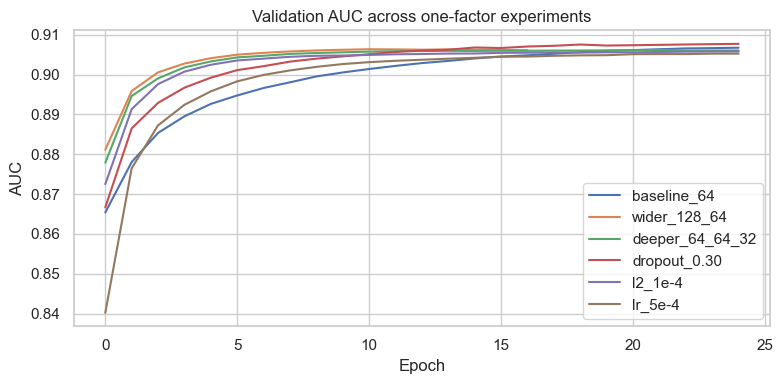

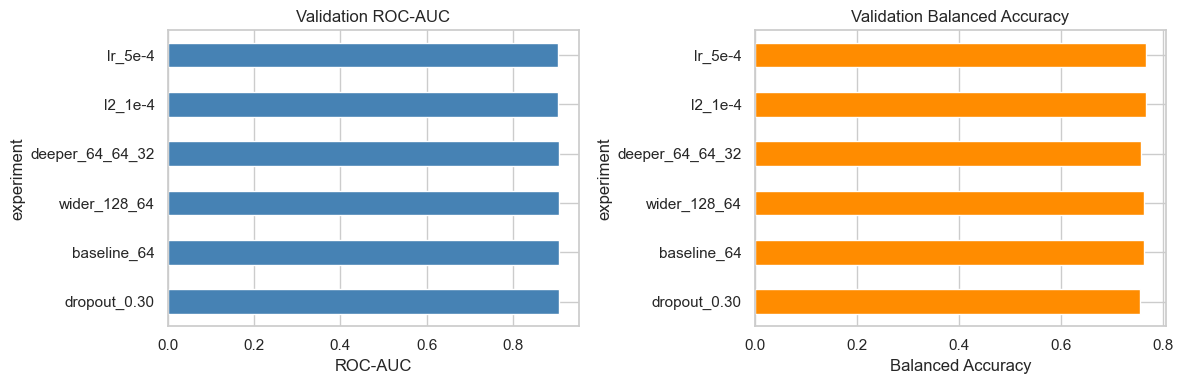

In [8]:
plot_history(experiment_histories, metric="auc", title="Validation AUC across one-factor experiments")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
results_df.plot(x="experiment", y="val_roc_auc", kind="barh", ax=ax[0], legend=False, color="steelblue")
ax[0].set_title("Validation ROC-AUC")
ax[0].set_xlabel("ROC-AUC")

results_df.plot(
    x="experiment", y="val_balanced_accuracy", kind="barh", ax=ax[1], legend=False, color="darkorange"
)
ax[1].set_title("Validation Balanced Accuracy")
ax[1].set_xlabel("Balanced Accuracy")
plt.tight_layout()
plt.show()

### Takeaways from one-factor experiments

- **Architecture:** A wider two-layer network (`128→64`) and moderate L2 regularization gave the best balanced accuracy among architecture-only changes. The very deep `64→64→32` network trained faster (early stopping kicked in sooner) but did not improve validation metrics — likely more capacity than this tabular feature set needs.
- **Regularization:** Dropout helped AUC slightly but hurt balanced accuracy, which suggests the default 0.5 threshold became less balanced for the minority `>50K` class. L2 was a safer regularizer here.
- **Optimization:** Lower learning rate (`5e-4`) was competitive but did not clearly beat the baseline; training curves were smoother, not necessarily better at the end.
- **Overall:** Validation ROC-AUC was fairly stable (~0.905–0.908) across configs, so I used AUC as the primary metric for hyperparameter search because the classes are imbalanced.

## 6. Systematic tuning with Optuna

After the controlled experiments, I used Optuna (TPE sampler) to search jointly over depth, width, dropout, L2, learning rate, and batch size. Each trial uses early stopping on validation AUC.

In [9]:
def optuna_objective(trial):
    n_layers = trial.suggest_int("n_layers", 1, 3)
    units = trial.suggest_categorical("units", [32, 64, 128])
    dropout = trial.suggest_float("dropout", 0.0, 0.5)
    l2 = trial.suggest_float("l2", 1e-6, 1e-3, log=True)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 3e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [256, 512])

    hidden_units = tuple([units] * n_layers)

    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(RANDOM_STATE)

    model = build_mlp(
        hidden_units=hidden_units,
        dropout=dropout,
        l2=l2,
        learning_rate=learning_rate,
    )

    history = train_model(
        model,
        X_train_s,
        y_train,
        X_val_s,
        y_val,
        epochs=20,
        batch_size=batch_size,
        patience=5,
    )
    metrics = evaluate_model(model, X_val_s, y_val)
    return metrics["roc_auc"]


study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
study.optimize(optuna_objective, n_trials=20, show_progress_bar=True)

print("Best validation ROC-AUC:", round(study.best_value, 4))
print("Best hyperparameters:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

  0%|          | 0/20 [00:00<?, ?it/s]

Best validation ROC-AUC: 0.9092
Best hyperparameters:
  n_layers: 2
  units: 128
  dropout: 0.4171981962581277
  l2: 3.637842038106253e-05
  learning_rate: 0.0018276039874898934
  batch_size: 512


In [10]:
trials_df = study.trials_dataframe().sort_values("value", ascending=False)
trials_df[["number", "value", "params_n_layers", "params_units", "params_dropout", "params_learning_rate", "params_batch_size"]].head(10)

,number,value,params_n_layers,params_units,params_dropout,params_learning_rate,params_batch_size
16,16,0.909161,2,128,0.417198,0.001828,512
12,12,0.908545,3,64,0.361997,0.001552,512
7,7,0.908335,2,64,0.401098,0.002869,256
13,13,0.908244,3,64,0.322919,0.001412,512
17,17,0.908038,3,128,0.282259,0.000950,512
10,10,0.907925,3,64,0.484769,0.002840,512
11,11,0.907750,3,64,0.483254,0.002923,512
9,9,0.907422,2,32,0.162592,0.000874,256
3,3,0.907298,2,128,0.085262,0.002521,256
19,19,0.907169,2,128,0.322350,0.000677,512


## 7. Final model training and test-set evaluation

The test set stayed untouched during preprocessing fit, experiments, and Optuna. For the final model I:
1. Combined train + validation data
2. Refit the scaler on the combined training data
3. Retrained with the best Optuna settings and a small internal validation split for early stopping
4. Evaluated once on the held-out test set

In [11]:
best = study.best_params
best_hidden = tuple([best["units"]] * best["n_layers"])

# combine train + val for final fit
X_train_all = pd.concat([X_train, X_val], axis=0)
y_train_all = pd.concat([y_train, y_val], axis=0)

final_scaler = StandardScaler()
X_train_all_s = final_scaler.fit_transform(X_train_all)
X_test_final_s = final_scaler.transform(X_test)

X_tr_final, X_va_final, y_tr_final, y_va_final = train_test_split(
    X_train_all_s,
    y_train_all,
    test_size=0.10,
    random_state=RANDOM_STATE,
    stratify=y_train_all,
)

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(RANDOM_STATE)

final_model = build_mlp(
    hidden_units=best_hidden,
    dropout=best["dropout"],
    l2=best["l2"],
    learning_rate=best["learning_rate"],
)

final_history = train_model(
    final_model,
    X_tr_final,
    y_tr_final,
    X_va_final,
    y_va_final,
    epochs=40,
    batch_size=best["batch_size"],
    patience=8,
    verbose=1,
)

test_metrics = evaluate_model(final_model, X_test_final_s, y_test)
baseline_test = evaluate_model(baseline, X_test_s, y_test)

comparison = pd.DataFrame(
    [
        {
            "model": "baseline (val)",
            "balanced_accuracy": baseline_metrics["balanced_accuracy"],
            "roc_auc": baseline_metrics["roc_auc"],
        },
        {
            "model": "baseline (test)",
            "balanced_accuracy": baseline_test["balanced_accuracy"],
            "roc_auc": baseline_test["roc_auc"],
        },
        {
            "model": "tuned final (test)",
            "balanced_accuracy": test_metrics["balanced_accuracy"],
            "roc_auc": test_metrics["roc_auc"],
        },
    ]
)
comparison

Epoch 1/40
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8122 - auc: 0.8398 - loss: 0.4075 - val_accuracy: 0.8327 - val_auc: 0.8862 - val_loss: 0.3535
Epoch 2/40
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8331 - auc: 0.8823 - loss: 0.3585 - val_accuracy: 0.8390 - val_auc: 0.8943 - val_loss: 0.3410
Epoch 3/40
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8408 - auc: 0.8884 - loss: 0.3500 - val_accuracy: 0.8434 - val_auc: 0.8984 - val_loss: 0.3338
Epoch 4/40
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8425 - auc: 0.8921 - loss: 0.3444 - val_accuracy: 0.8424 - val_auc: 0.9005 - val_loss: 0.3308
Epoch 5/40
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8419 - auc: 0.8931 - loss: 0.3422 - val_accuracy: 0.8416 - val_auc: 0.9006 - val_loss: 0.3302
Epoch 6/40
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8440 - auc: 0.8960 - loss: 0.3384 - val_accuracy: 0.8444 - val_auc: 0.9018 - val_loss: 0.3283
Epoch 7/40
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - 

,model,balanced_accuracy,roc_auc
0,baseline (val),0.761621,0.906885
1,baseline (test),0.763026,0.904854
2,tuned final (test),0.752935,0.907794


Classification report — tuned model on test set
              precision    recall  f1-score   support

       <=50K       0.87      0.95      0.91      7431
        >50K       0.77      0.56      0.65      2338

    accuracy                           0.85      9769
   macro avg       0.82      0.75      0.78      9769
weighted avg       0.85      0.85      0.85      9769



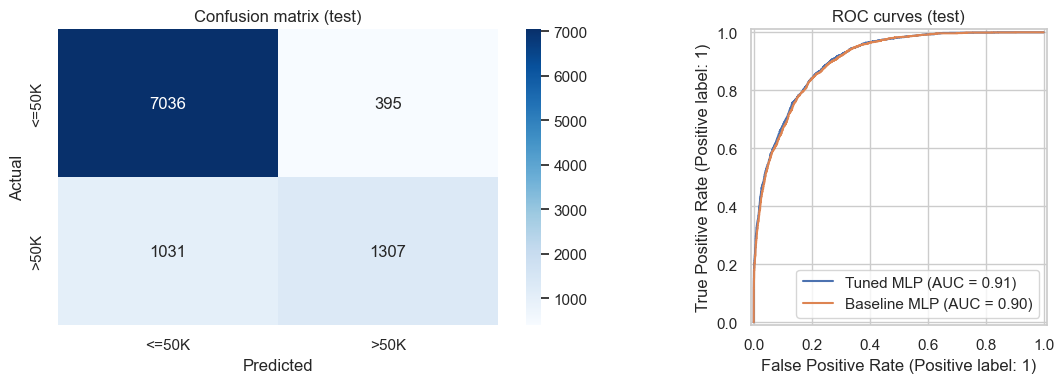

In [12]:
print("Classification report — tuned model on test set")
print(
    classification_report(
        y_test,
        test_metrics["preds"],
        target_names=["<=50K", ">50K"],
    )
)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

cm = confusion_matrix(y_test, test_metrics["preds"])
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["<=50K", ">50K"],
    yticklabels=["<=50K", ">50K"],
    ax=ax[0],
)
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("Actual")
ax[0].set_title("Confusion matrix (test)")

RocCurveDisplay.from_predictions(y_test, test_metrics["probs"], ax=ax[1], name="Tuned MLP")
RocCurveDisplay.from_predictions(
    y_test, baseline_test["probs"], ax=ax[1], name="Baseline MLP"
)
ax[1].set_title("ROC curves (test)")
plt.tight_layout()
plt.show()

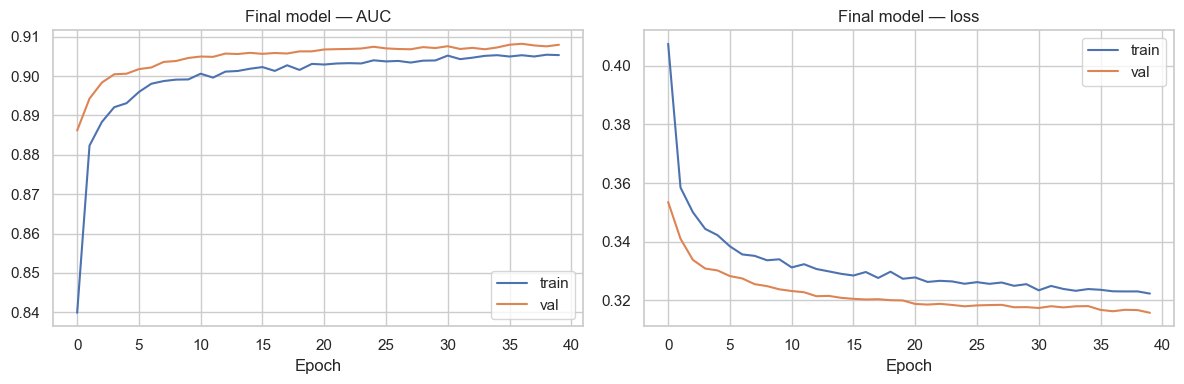

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(final_history.history["auc"], label="train")
ax[0].plot(final_history.history["val_auc"], label="val")
ax[0].set_title("Final model — AUC")
ax[0].set_xlabel("Epoch")
ax[0].legend()

ax[1].plot(final_history.history["loss"], label="train")
ax[1].plot(final_history.history["val_loss"], label="val")
ax[1].set_title("Final model — loss")
ax[1].set_xlabel("Epoch")
ax[1].legend()
plt.tight_layout()
plt.show()

### Final evaluation summary

**Context:** On the same preprocessed features, our in-class XGBoost baseline reached about **0.84 test balanced accuracy**. The neural network is competitive on ROC-AUC (~0.91) but lower on balanced accuracy with a 0.5 threshold because it under-recalls the minority `>50K` class.

**Training behavior:** Train and validation AUC tracked closely in the final model, which suggests limited overfitting after dropout/L2 and early stopping. Validation loss flattened while AUC still improved slightly — a sign the model was ranking better even as calibrated probabilities stabilized.

**Metrics:** For imbalanced census income data, I would report **ROC-AUC** and **balanced accuracy** together, and consider threshold tuning if the business goal is to catch more high earners rather than maximize overall accuracy.

## 8. Personal workflow for building neural networks

This is the checklist I would reuse on future tabular NN projects:

1. **Start with a strong tabular baseline.** Tree models (XGBoost/LightGBM) on the same features set a performance bar and help validate preprocessing.
2. **Prepare data specifically for NNs.** Encode categoricals, scale numeric inputs, and keep a strict train/validation/test split. Fit all transformers on training data only.
3. **Build a tiny baseline MLP first.** One hidden layer, modest width, ReLU + sigmoid output, Adam optimizer. Confirm the pipeline runs and loss decreases.
4. **Change one factor at a time.** Test depth/width, then regularization, then learning rate/batch size. Log validation curves, not just final scores.
5. **Pick the right metric early.** Accuracy can look good on imbalanced data while missing the minority class; balanced accuracy, ROC-AUC, or PR-AUC are usually more informative.
6. **Use early stopping + systematic search.** Once promising regions appear, run Optuna/grid search on a bounded space instead of hand-tuning every knob.
7. **Retrain on train+val, evaluate once on test.** After tuning, refit with the best config and only then touch the held-out test set.
8. **Watch for common pitfalls.**
   - Data leakage from scaling/encoding on the full dataset
   - Using too deep a network on small tabular feature sets
   - Chasing validation AUC while ignoring recall on the minority class
   - Forgetting to set random seeds when comparing architectures

**Bottom line:** For tabular problems like census income, neural nets can match strong AUC quickly, but thoughtful preprocessing and threshold-aware evaluation matter as much as architecture choices.